# **Solución Prueba Técnica**

## **Punto 1**

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve

In [62]:
# Leer el dataset con codificación UTF-8 para manejar tildes correctamente
path = '../datosentrada/dataset_prueba_adherencia.csv'
df = pd.read_csv(path, sep=';', encoding='utf-8', 
                 parse_dates=['fecha_recepcion', 'fecha_inicio_tratamiento'], 
                 dayfirst=True)

# Limpiar nombres de columnas (quitar espacios en blanco)
df.columns = df.columns.str.strip()

# Limpiar campos de texto (quitar espacios en blanco si existen)
df_obj = df.select_dtypes(['object'])
df[df_obj.columns] = df_obj.apply(lambda x: x.str.strip() if hasattr(x, 'str') else x)

# Describir la base de datos
print("--- Estadísticas Descriptivas ---")
display(df.describe())
print("\n--- Valores Nulos (sin tratar aún) ---")
display(df.isnull().sum())
print(f"\n--- Tamaño de la base de datos (size) ---\n{df.shape}")

# Verificar tipos de datos
print("\n--- Tipos de Datos ---")
display(df.dtypes)

--- Estadísticas Descriptivas ---


,id_paciente,fecha_recepcion,fecha_inicio_tratamiento,edad,dosis_actual,semana_tratamiento,total_llamadas,llamadas_contestadas,duracion_promedio_seg,dias_desde_ultima_llamada,...,sentimiento_ultima_llamada,sentimiento_promedio,cambio_sentimiento_ultimas_2,mencion_abandono,mencion_efectos_secundarios,mencion_costo,mencion_acceso_medicamento,engagement_score,ratio_habla_paciente,abandono_30d
count,500.000000,500,500,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,468.000000,384.000000,354.000000,500.000000,500.000000,500.000000,500.00000,422.000000,468.000000,500.000000
mean,200249.500000,2025-07-01 15:38:52.800000,2025-07-26 07:17:45.600000,54.558000,7.533800,28.172000,12.612000,7.158000,244.166600,46.348000,...,-0.045598,0.148854,-0.156271,0.120000,0.272000,0.194000,0.15200,0.558270,0.398312,0.428000
min,200000.000000,2025-01-01 00:00:00,2025-01-04 00:00:00,18.000000,0.250000,1.000000,1.000000,0.000000,0.000000,1.000000,...,-1.000000,-0.490000,-0.600000,0.000000,0.000000,0.000000,0.00000,0.100000,0.150000,0.000000
25%,200124.750000,2025-03-26 18:00:00,2025-04-21 18:00:00,44.000000,1.000000,15.000000,6.000000,3.000000,126.125000,23.000000,...,-0.560000,-0.170000,-0.370000,0.000000,0.000000,0.000000,0.00000,0.330000,0.287500,0.000000
50%,200249.500000,2025-07-01 00:00:00,2025-07-26 00:00:00,55.000000,2.400000,28.000000,13.000000,6.000000,252.950000,47.000000,...,-0.050000,0.155000,-0.160000,0.000000,0.000000,0.000000,0.00000,0.560000,0.400000,0.000000
75%,200374.250000,2025-10-06 12:00:00,2025-10-29 00:00:00,64.000000,7.000000,43.000000,19.000000,11.000000,370.450000,69.000000,...,0.475000,0.492500,0.060000,0.000000,1.000000,0.000000,0.00000,0.780000,0.510000,1.000000
max,200499.000000,2025-12-31 00:00:00,2026-02-07 00:00:00,90.000000,50.000000,52.000000,25.000000,21.000000,479.200000,90.000000,...,1.000000,0.800000,0.300000,1.000000,1.000000,1.000000,1.00000,1.000000,0.650000,1.000000
std,144.481833,NaN,NaN,14.391834,12.864678,15.207793,7.526936,5.299548,141.207589,26.340892,...,0.580504,0.372086,0.254354,0.325287,0.445436,0.395825,0.35938,0.257523,0.141270,0.495284



--- Valores Nulos (sin tratar aún) ---


id_paciente                             0
fecha_recepcion                         0
fecha_inicio_tratamiento                0
canal                                   0
genero                                 70
edad                                    0
departamento                            0
eps                                     0
especialidad_medico                     0
terapia                                 0
unidad_negocio                          0
dosis_actual                            0
semana_tratamiento                      0
estado_paciente                         0
estado_tratamiento                      0
sub_estado_tratamiento                  0
barrera                                 0
perfil_paciente                         0
total_llamadas                          0
llamadas_contestadas                    0
duracion_promedio_seg                   0
dias_desde_ultima_llamada               0
intentos_sin_contacto_consecutivos      0
num_dispensaciones                


--- Tamaño de la base de datos (size) ---
(500, 40)

--- Tipos de Datos ---


id_paciente                                    int64
fecha_recepcion                       datetime64[us]
fecha_inicio_tratamiento              datetime64[us]
canal                                            str
genero                                           str
edad                                           int64
departamento                                     str
eps                                              str
especialidad_medico                              str
terapia                                          str
unidad_negocio                                   str
dosis_actual                                 float64
semana_tratamiento                             int64
estado_paciente                                  str
estado_tratamiento                               str
sub_estado_tratamiento                           str
barrera                                          str
perfil_paciente                                  str
total_llamadas                                

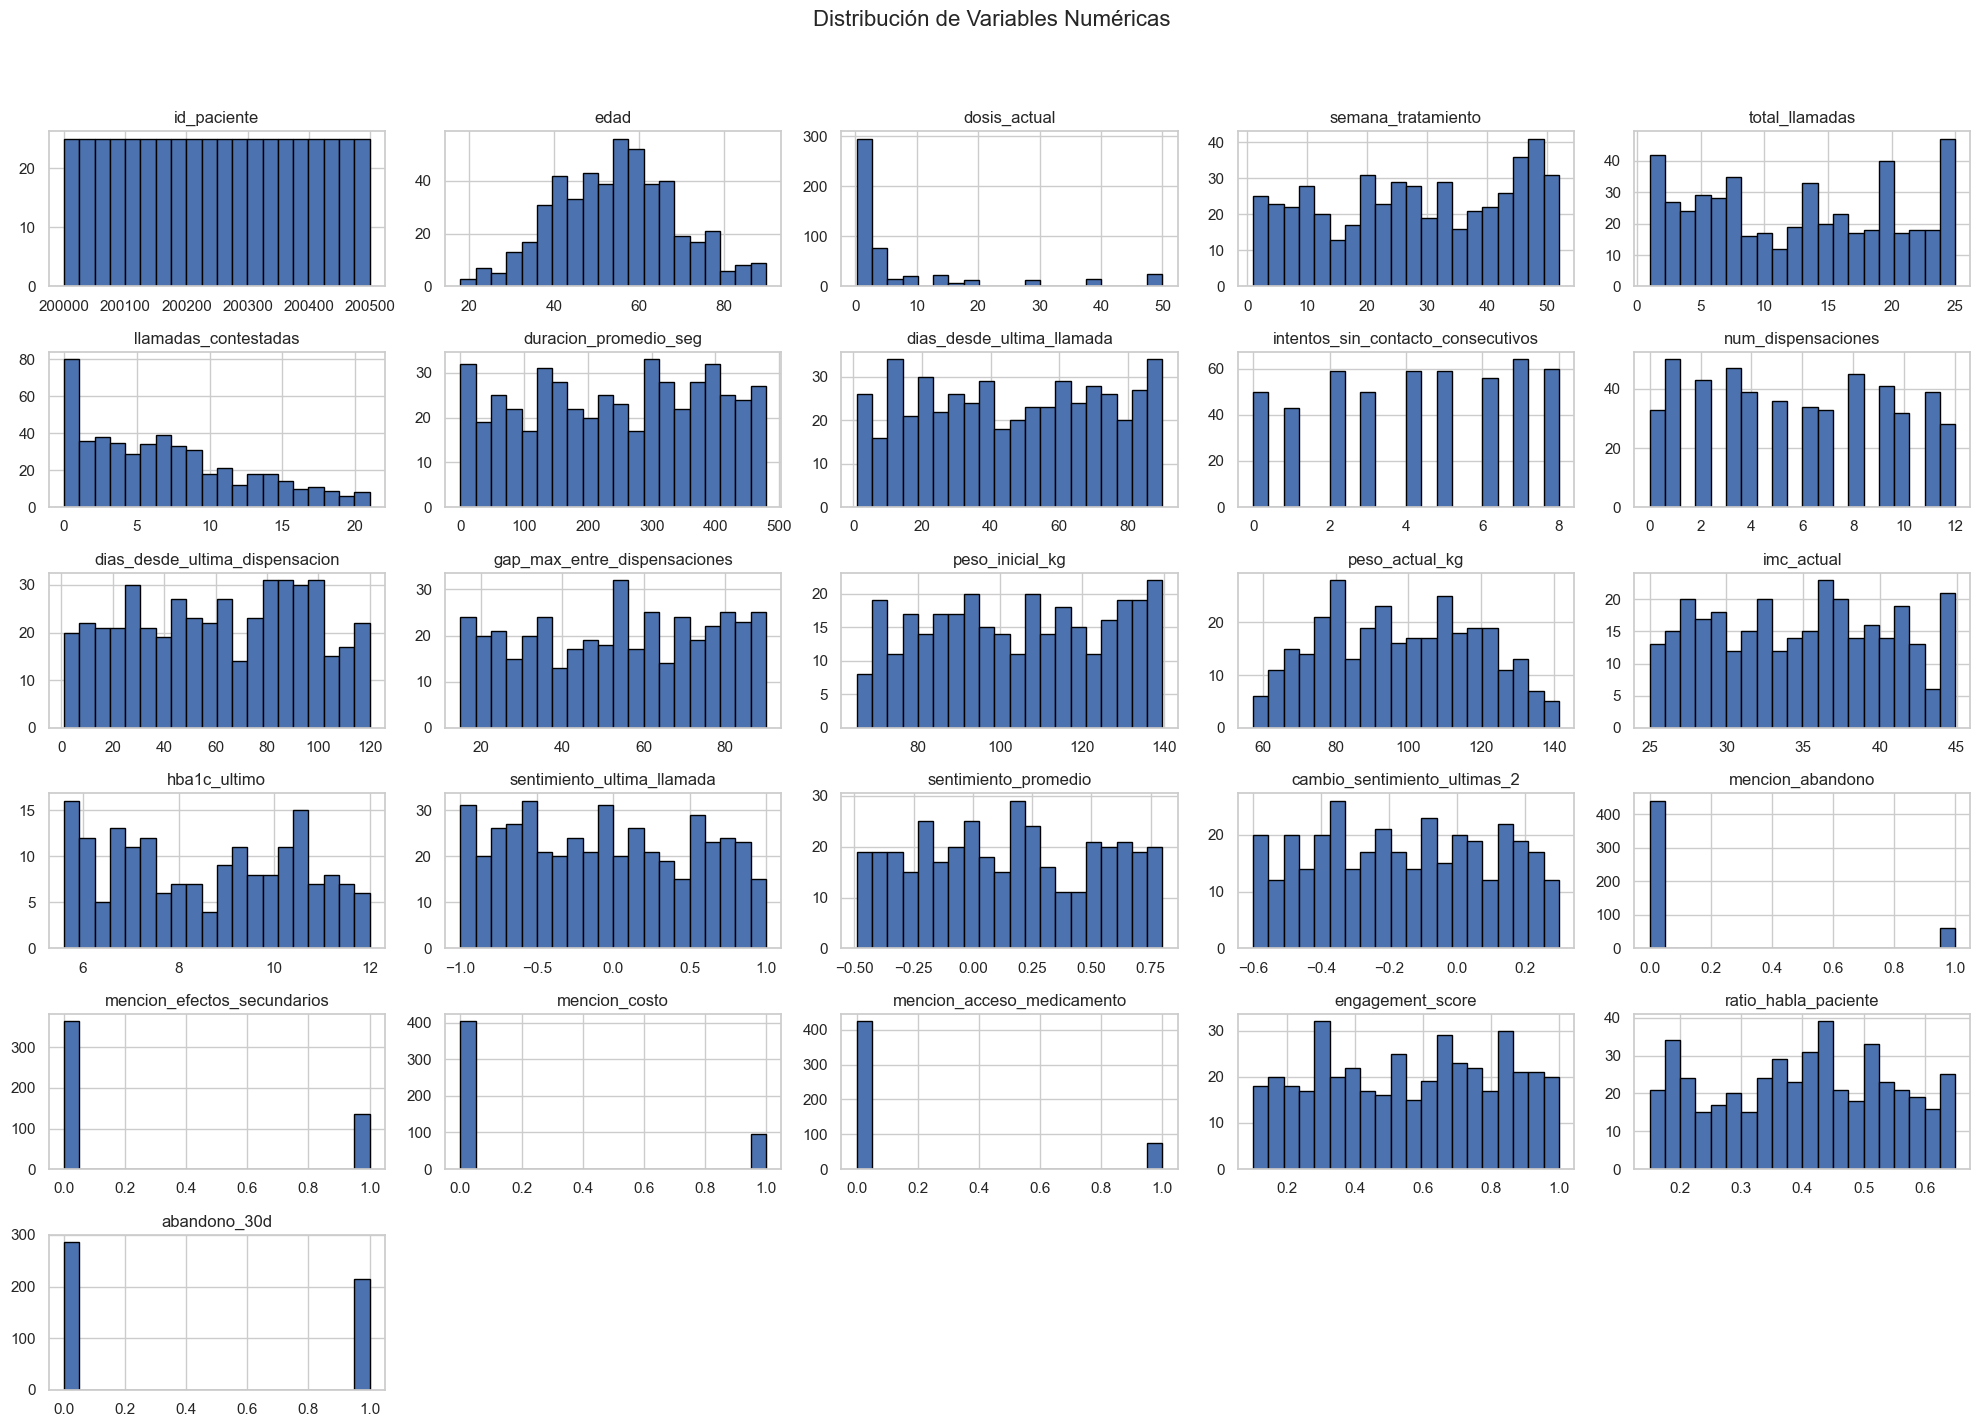

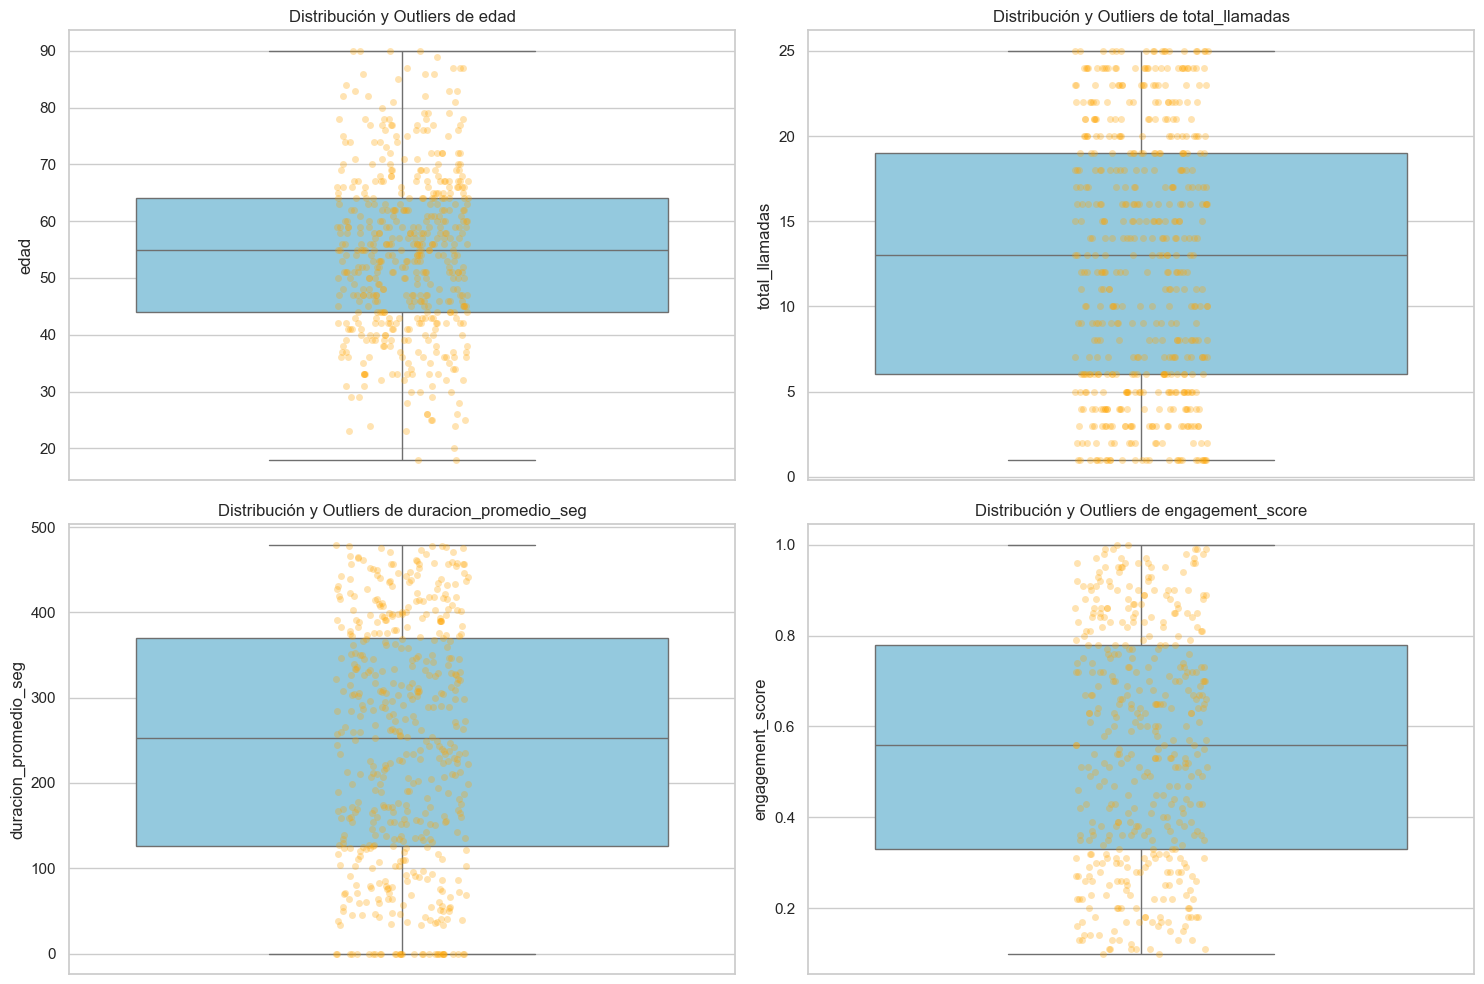

In [63]:
# Visualizar distribuciones de variables numéricas
df_numeric = df.select_dtypes(include=[np.number])

# Histogramas
df_numeric.hist(figsize=(20, 15), bins=20, edgecolor='black')
plt.suptitle('Distribución de Variables Numéricas', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Diagramas de Caja (Boxplots) con puntos para ver outliers claramente
cols_to_plot = ['edad', 'total_llamadas', 'duracion_promedio_seg', 'engagement_score']
cols_present = [c for c in cols_to_plot if c in df.columns]

if cols_present:
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(cols_present, 1):
        plt.subplot(2, 2, i)
        # Boxplot base
        sns.boxplot(y=df[col], color="skyblue", showfliers=True)
        # Overlay de puntos (stripplot) para ver la distribución real y outliers
        sns.stripplot(y=df[col], color="orange", alpha=0.3, jitter=True)
        plt.title(f'Distribución y Outliers de {col}')
    plt.tight_layout()
    plt.show()

In [64]:
def analizar_abandono(df):
    target = 'abandono_30d'
    # Segmentos solicitados
    segmentos = ['terapia', 'unidad_negocio', 'barrera', 'perfil_paciente']
    
    print(f"=== ANÁLISIS DE TASA DE ABANDONO (Variable: {target}) ===")
    tasa_global = df[target].mean()
    print(f"Tasa de Abandono Global: {tasa_global:.2%}\n")
    
    for seg in segmentos:
        if seg in df.columns:
            # Calcular tasa y conteo por segmento
            stats = df.groupby(seg)[target].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
            stats.columns = ['Tasa Abandono', 'Nro Pacientes']
            
            print(f"--- Segmentación por: {seg.replace('_', ' ').upper()} ---")
            # Mostrar los valores para análisis
            display(stats.style.format({'Tasa Abandono': '{:.2%}'}))
            print("\n")
        else:
            print(f"Variable {seg} no encontrada en el dataset.\n")

analizar_abandono(df)

=== ANÁLISIS DE TASA DE ABANDONO (Variable: abandono_30d) ===
Tasa de Abandono Global: 42.80%

--- Segmentación por: TERAPIA ---


,Tasa Abandono,Nro Pacientes
terapia,,
X,65.00%,20
T,63.64%,11
R,50.88%,57
O,48.05%,77
S,40.36%,275
Y,35.71%,14
W,26.19%,42
V,25.00%,4




--- Segmentación por: UNIDAD NEGOCIO ---


,Tasa Abandono,Nro Pacientes
unidad_negocio,,
Diabetes,50.27%,183
Obesidad,38.49%,317




--- Segmentación por: BARRERA ---


,Tasa Abandono,Nro Pacientes
barrera,,
BARRERA_EPS,50.00%,24
NO_APLICA,43.97%,282
SIN_BARRERA,43.86%,57
BARRERA_PACIENTE,39.62%,106
BARRERA_MEDICO,35.48%,31




--- Segmentación por: PERFIL PACIENTE ---


,Tasa Abandono,Nro Pacientes
perfil_paciente,,
Sin brújula,49.18%,61
Sedentarios,47.17%,53
Alpinista Inconsciente - Asistido,45.76%,59
Alpinista Inconsciente - Desorientado,43.55%,62
Alpinista Consciente - Precavido,42.22%,45
Alpinista Inconsciente - Desinteresado,40.82%,49
Asistidos,40.32%,62
Trotamundos,38.30%,47
Alpinista Consciente - Profesional,37.10%,62


**¿Qué segmentos tienen mayor riesgo?**

Dadas las tasas de abandono a nivel global y por segmento, concluimos que en el segmento donde mayor tasa de abandono se registra es en la terapia X con un porcentaje de 65%, mientras que en la unidad negocio "Diabetes" se presenta una tasa de abandono de 50.27%, el segmento de Barrera EPS presenta una tasa de abandono de 50%, y el perfil de paciente con más tasa de abandono es "Sin brújula" con un 49.18%, por lo tanto, el segmento que tiene mayor riesgo de abandono es el de terapia X.

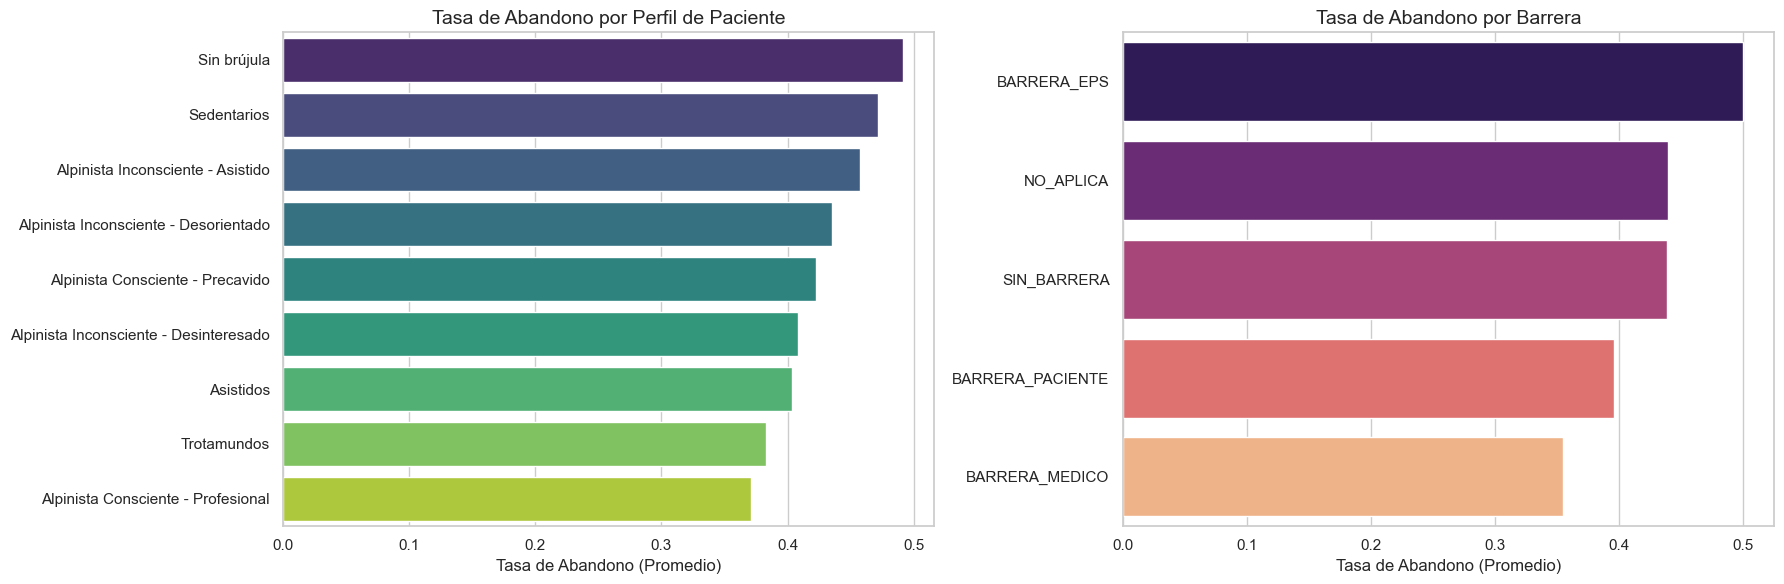

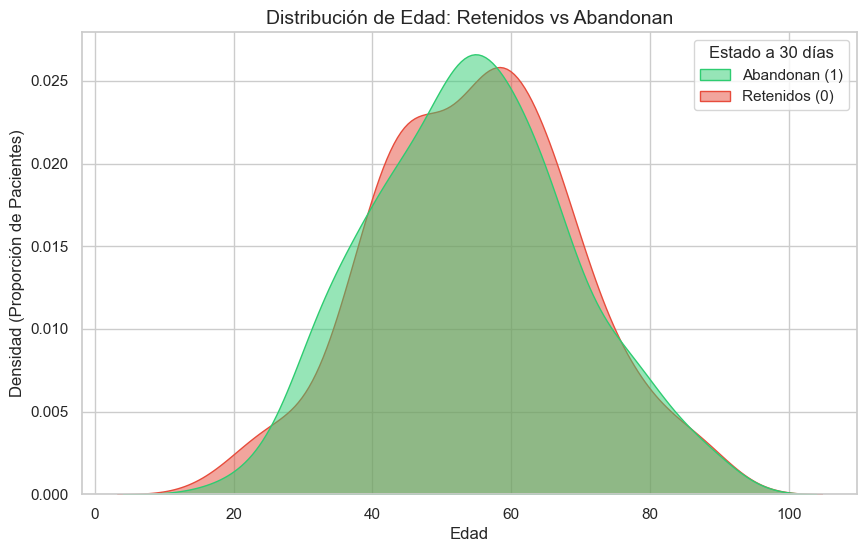

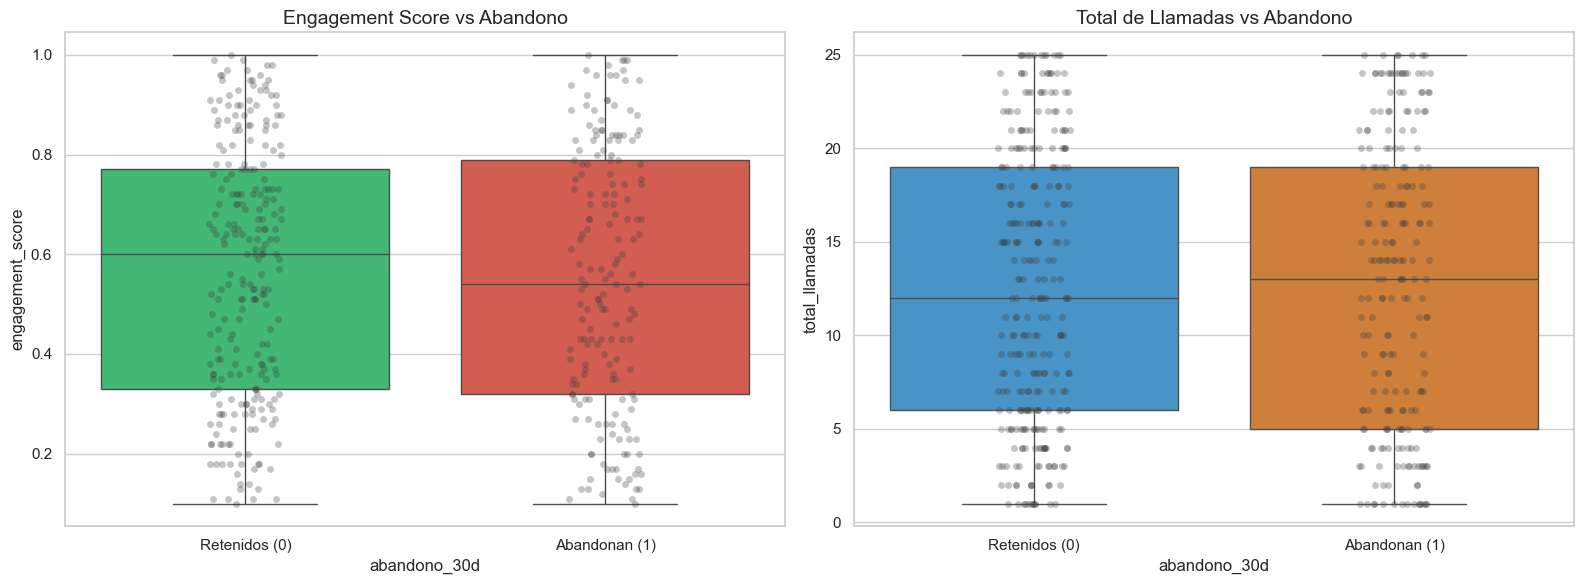

In [65]:
# ==========================================
# VISUALIZACIONES PARA ENTENDER EL ABANDONO
# ==========================================

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# IDEA 1: Gráfico de Barras - Tasa de Abandono por Perfil de Paciente y Barrera
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Ordenar por tasa de abandono para mejor lectura
orden_perfil = df.groupby('perfil_paciente')['abandono_30d'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='abandono_30d', y='perfil_paciente', order=orden_perfil, ax=axes[0], palette='viridis', errorbar=None)
axes[0].set_title('Tasa de Abandono por Perfil de Paciente', fontsize=14)
axes[0].set_xlabel('Tasa de Abandono (Promedio)')
axes[0].set_ylabel('')

orden_barrera = df.groupby('barrera')['abandono_30d'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='abandono_30d', y='barrera', order=orden_barrera, ax=axes[1], palette='magma', errorbar=None)
axes[1].set_title('Tasa de Abandono por Barrera', fontsize=14)
axes[1].set_xlabel('Tasa de Abandono (Promedio)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# IDEA 2: Distribución de la Edad según el Estado de Abandono (KDE Plot)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='edad', hue='abandono_30d', fill=True, common_norm=False, palette=['#2ecc71', '#e74c3c'], alpha=0.5)
plt.title('Distribución de Edad: Retenidos vs Abandonan', fontsize=14)
plt.xlabel('Edad')
plt.ylabel('Densidad (Proporción de Pacientes)')
# Actualizar leyenda para mayor claridad
handles = plt.gca().get_legend().legend_handles
plt.legend(handles=handles, title='Estado a 30 días', labels=['Abandonan (1)', 'Retenidos (0)'])
plt.show()

# IDEA 3: Impacto del Engagement y Total de Llamadas en el Abandono (Boxplots)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='abandono_30d', y='engagement_score', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
sns.stripplot(data=df, x='abandono_30d', y='engagement_score', color=".25", alpha=0.3, jitter=True, ax=axes[0])
axes[0].set_title('Engagement Score vs Abandono', fontsize=14)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retenidos (0)', 'Abandonan (1)'])

sns.boxplot(data=df, x='abandono_30d', y='total_llamadas', ax=axes[1], palette=['#3498db', '#e67e22'])
sns.stripplot(data=df, x='abandono_30d', y='total_llamadas', color=".25", alpha=0.3, jitter=True, ax=axes[1])
axes[1].set_title('Total de Llamadas vs Abandono', fontsize=14)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Retenidos (0)', 'Abandonan (1)'])

plt.tight_layout()
plt.show()

Realicé tres gráficos para visualizar el comportamiento de los abandonos. El primero nos muestra la comparación entre las tasas de abandono por el perfil del paciente y por barrera, esto con la idea de verificar si en alguno de estos segmentos se evidencia claramente un abandono diferente. El segundo es un gráfico que muestra la densidad de abandono por edad, y también la densidad de los que no abandonan, se puede observar que la población tanto de los que más abandonan como de los que no, ronda por la misma edad, esto es estratégico porque si enfocamos fuerzas en este sector, podremos retener más pacientes. Finalmente, tenemos un diagrama de boxplot para comparar el comportamiento del engagement_score de los que abandonan y los que no, y en general, aquellos que abandonan presentan en su mayoría un engagement_score menor al de los retenidos, mientras que el boxplot de total llamadas es al revés, realizan más llamadas los que abandonan que los retenidos.

## **Punto 2**

### Tratamiento de Nulos y Outliers

**Estrategia de Nulos:**
- `genero`: Imputado con la categoría constante `'No reportado'`.
- **Métricas de llamadas y sentimiento** (`engagement_score`, `ratio_habla_paciente`, `sentimiento_ultima_llamada`, etc.): Imputados con `0`, asumiendo que si el dato falta es porque no hubo interacción o el sentimiento es neutral.
- **Métricas clínicas** (`peso_inicial_kg`, `peso_actual_kg`, `imc_actual`, `hba1c_ultimo`): Imputadas con la **mediana** de la población para no sesgar las distribuciones ni verse afectadas por valores extremos.
- **Métricas de dispensación** (`dias_desde_ultima_dispensacion`, `gap_max_entre_dispensaciones`): Imputadas con `-1` para diferenciar a los pacientes que nunca han tenido una dispensación.

**Estrategia de Outliers:**
- Se utilizó **Capping (Winsorización) mediante el Rango Intercuartílico (IQR)** para las variables numéricas continuas. Los valores extremos por encima de `Q3 + 1.5 * IQR` se limitan a ese umbral superior, y los que están por debajo de `Q1 - 1.5 * IQR` se limitan al umbral inferior. Esto ayuda a mantener todas las observaciones (filas) pero reduce el impacto negativo de los outliers en el modelo.

In [66]:
# ==========================================
# 1. TRATAMIENTO DE NULOS Y OUTLIERS
# ==========================================

# A. TRATAMIENTO DE NULOS
# 1. Variables categóricas
df['genero'] = df['genero'].fillna('No reportado')

# 2. Métricas de interacción y sentimiento (imputar con 0)
cols_interaccion = ['engagement_score', 'ratio_habla_paciente', 
                    'sentimiento_ultima_llamada', 'sentimiento_promedio', 'cambio_sentimiento_ultimas_2']
df[cols_interaccion] = df[cols_interaccion].fillna(0)

# 3. Métricas clínicas (imputar con mediana)
cols_clinicas = ['peso_inicial_kg', 'peso_actual_kg', 'imc_actual', 'hba1c_ultimo']
for col in cols_clinicas:
    df[col] = df[col].fillna(df[col].median())

# 4. Métricas de dispensación (imputar con -1, indica "nunca dispensado")
cols_dispensacion = ['dias_desde_ultima_dispensacion', 'gap_max_entre_dispensaciones']
df[cols_dispensacion] = df[cols_dispensacion].fillna(-1)

print("Verificación de nulos post-imputación:")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Debería estar vacío

# B. TRATAMIENTO DE OUTLIERS (Capping con IQR)
cols_continuas = ['edad', 'duracion_promedio_seg', 'total_llamadas', 'dias_desde_ultima_llamada']

for col in cols_continuas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Capping
    df[col] = np.where(df[col] > limite_superior, limite_superior, 
                       np.where(df[col] < limite_inferior, limite_inferior, df[col]))

print(f"\nCapping de outliers aplicado a: {cols_continuas}")

Verificación de nulos post-imputación:
Series([], dtype: int64)

Capping de outliers aplicado a: ['edad', 'duracion_promedio_seg', 'total_llamadas', 'dias_desde_ultima_llamada']


### Variables Derivadas (Feature Engineering)

He seleccionado tres variables nuevas que aportan gran valor de negocio y predictivo para el modelo:

1. **`tiempo_espera_tratamiento` (días)**: Diferencia entre la `fecha_inicio_tratamiento` y la `fecha_recepcion`. 
   - Un tiempo de espera prolongado genera fricción inicial en la experiencia del paciente y suele ser un factor predictivo temprano del abandono.
2. **`tasa_contestacion`**: Proporción de `llamadas_contestadas` sobre el `total_llamadas`. 
   - Normaliza la interacción. Un paciente con muchas llamadas totales pero baja tasa de contestación demuestra alta resistencia al programa, lo que es un fuerte indicador de deserción en comparación a simplemente mirar el total de llamadas.
3. **`variacion_peso`**: Diferencia entre `peso_actual_kg` y `peso_inicial_kg`. 
   - Captura la evolución clínica. Ganancia o pérdida de peso drástica puede estar correlacionada con una baja adherencia a terapias crínicas (como diabetes u obesidad) o desmotivación del paciente.

In [67]:
# ==========================================
# 2. CREACIÓN DE VARIABLES DERIVADAS
# ==========================================

# 1. Tiempo de espera (en días)
# Nos aseguramos de que las fechas sean de tipo datetime
df['fecha_recepcion'] = pd.to_datetime(df['fecha_recepcion'])
df['fecha_inicio_tratamiento'] = pd.to_datetime(df['fecha_inicio_tratamiento'])

df['tiempo_espera_tratamiento'] = (df['fecha_inicio_tratamiento'] - df['fecha_recepcion']).dt.days

# 2. Tasa de contestación
# Prevenimos la división por cero usando np.where
df['tasa_contestacion'] = np.where(df['total_llamadas'] > 0, 
                                   df['llamadas_contestadas'] / df['total_llamadas'], 
                                   0)

# 3. Variación de peso
df['variacion_peso'] = df['peso_actual_kg'] - df['peso_inicial_kg']

display(df[['tiempo_espera_tratamiento', 'tasa_contestacion', 'variacion_peso']].head())

,tiempo_espera_tratamiento,tasa_contestacion,variacion_peso
0,9,0.727273,-7.6
1,37,0.750000,-3.3
2,17,0.500000,-7.6
3,7,0.461538,-15.1
4,34,0.000000,-7.6


### Transformación de Variables Categóricas (One-Hot Encoding)

Finalmente, aplicamos **One-Hot Encoding (OHE)** a todas las variables categóricas mediante `pd.get_dummies()`. 
- *Por qué OHE*: Esta técnica crea columnas binarias (0 y 1) independientes para cada categoría. Es esencial porque si usáramos una técnica ordinal (ej. Label Encoding, asignando 1, 2, 3...), los modelos (especialmente los basados en distancias) asumirían matemáticamente que la categoría 3 "es mayor" o "está más lejos" de la 1, lo cual es falso para variables sin un orden inherente como `departamento` o `terapia`.
- Además, eliminaremos las columnas de texto originales y las de tipo fecha que ya no son legibles por el modelo (`id_paciente`, `fecha_recepcion`, `fecha_inicio_tratamiento`) para entregar el dataframe `df_ml` 100% numérico, garantizando que esté completamente listo para la fase de entrenamiento.

In [68]:
# ==========================================
# 3. TRANSFORMACIÓN ONE-HOT ENCODING
# ==========================================

# Identificar columnas categóricas nominales
cols_categoricas = ['canal', 'genero', 'departamento', 'eps', 'especialidad_medico', 
                    'terapia', 'unidad_negocio', 'estado_paciente', 'estado_tratamiento', 
                    'sub_estado_tratamiento', 'barrera', 'perfil_paciente']

# Aplicar get_dummies (drop_first=True ayuda a evitar multicolinealidad, 
# creando n-1 variables por cada categoría original)
df_encoded = pd.get_dummies(df, columns=cols_categoricas, drop_first=True, dtype=int)

# Eliminar variables originales que ya no aportan al modelo (ID y fechas) 
# tras haber extraído el valor de las fechas en las variables derivadas.
columnas_a_eliminar = ['id_paciente', 'fecha_recepcion', 'fecha_inicio_tratamiento']
df_ml = df_encoded.drop(columns=[col for col in columnas_a_eliminar if col in df_encoded.columns])

print("Transformación One-Hot y limpieza exitosa.")
print(f"Dimensión original (df): {df.shape}")
print(f"Dimensión final lista para ML (df_ml): {df_ml.shape}")
display(df_ml.head())

Transformación One-Hot y limpieza exitosa.
Dimensión original (df): (500, 43)
Dimensión final lista para ML (df_ml): (500, 87)


,edad,dosis_actual,semana_tratamiento,total_llamadas,llamadas_contestadas,duracion_promedio_seg,dias_desde_ultima_llamada,intentos_sin_contacto_consecutivos,num_dispensaciones,dias_desde_ultima_dispensacion,...,barrera_NO_APLICA,barrera_SIN_BARRERA,perfil_paciente_Alpinista Consciente - Profesional,perfil_paciente_Alpinista Inconsciente - Asistido,perfil_paciente_Alpinista Inconsciente - Desinteresado,perfil_paciente_Alpinista Inconsciente - Desorientado,perfil_paciente_Asistidos,perfil_paciente_Sedentarios,perfil_paciente_Sin brújula,perfil_paciente_Trotamundos
0,62.0,0.25,49,22.0,16,275.4,76.0,6,0,-1.0,...,0,1,0,0,0,0,0,1,0,0
1,52.0,1.20,43,4.0,3,200.3,71.0,4,10,80.0,...,1,0,1,0,0,0,0,0,0,0
2,64.0,50.00,38,2.0,1,210.5,9.0,3,9,113.0,...,1,0,0,0,0,0,0,1,0,0
3,77.0,1.20,33,13.0,6,478.3,68.0,4,8,111.0,...,0,0,0,0,1,0,0,0,0,0
4,51.0,14.00,50,1.0,0,0.0,47.0,4,3,8.0,...,1,0,0,0,0,0,0,0,1,0


## **Punto 3**

### Partición de Datos (Train/Test Split)

Se realizará una partición de los datos asignando el **70% para entrenamiento** y el **30% para prueba**. 
Se aplica **estratificación** (`stratify=y`) para asegurar que la proporción de abandonos (1) y retenidos (0) sea exactamente la misma en ambos conjuntos, garantizando que los modelos aprendan y se evalúen sobre muestras representativas.
Además, se escalan las variables usando `StandardScaler`, lo cual es vital para el correcto funcionamiento matemático de la Regresión Logística.

In [69]:
# ==========================================
# 1. PARTICIÓN DE DATOS Y ESCALADO
# ==========================================

# Separar variables predictoras (X) de la variable objetivo (y)
X = df_ml.drop(columns=['abandono_30d'])
y = df_ml['abandono_30d']

# División 70/30 con estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Estandarización de las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dimensión de Entrenamiento: X={X_train.shape}, y={y_train.shape}")
print(f"Dimensión de Prueba: X={X_test.shape}, y={y_test.shape}")

Dimensión de Entrenamiento: X=(350, 86), y=(350,)
Dimensión de Prueba: X=(150, 86), y=(150,)


### Entrenamiento de Modelo 1: Regresión Logística

Este es un modelo paramétrico lineal excelente para establecer una línea base de desempeño. Entregaremos métricas completas de clasificación.

In [70]:
# ==========================================
# 2. MODELO: REGRESIÓN LOGÍSTICA
# ==========================================

print("=== RESULTADOS: REGRESIÓN LOGÍSTICA ===")
# Inicializar y entrenar el modelo con los datos escalados
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Métricas
metrics_lr = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'AUC-ROC': roc_auc_score(y_test, y_prob_lr)
}

for k, v in metrics_lr.items():
    print(f"{k}: {v:.4f}")

=== RESULTADOS: REGRESIÓN LOGÍSTICA ===
Accuracy: 0.6667
Precision: 0.5921
Recall: 0.7031
F1-Score: 0.6429
AUC-ROC: 0.7336


### Entrenamiento de Modelo 2: Random Forest

Este es un algoritmo de ensamble (basado en múltiples árboles de decisión) muy robusto. No requiere que los datos estén escalados, por lo que usaremos el set `X_train` original. Suele detectar relaciones complejas y no lineales mejor que el modelo anterior.

In [71]:
# ==========================================
# 3. MODELO: RANDOM FOREST
# ==========================================

print("=== RESULTADOS: RANDOM FOREST ===")
# Inicializar y entrenar el modelo
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Métricas
metrics_rf = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'AUC-ROC': roc_auc_score(y_test, y_prob_rf)
}

for k, v in metrics_rf.items():
    print(f"{k}: {v:.4f}")

=== RESULTADOS: RANDOM FOREST ===
Accuracy: 0.7267
Precision: 0.8108
Recall: 0.4688
F1-Score: 0.5941
AUC-ROC: 0.7597


### Evaluación Final: Matriz de Confusión y Curva ROC del Mejor Modelo

Se compara de manera programática cuál de los dos algoritmos obtuvo un mayor área bajo la curva (AUC-ROC), que es una de las métricas más confiables para problemas de clasificación. Con base en el ganador, se generará la **Matriz de Confusión** (para ver falsos positivos y negativos) y la **Curva ROC**.


---> Mejor Modelo Seleccionado (por AUC-ROC): Random Forest <---



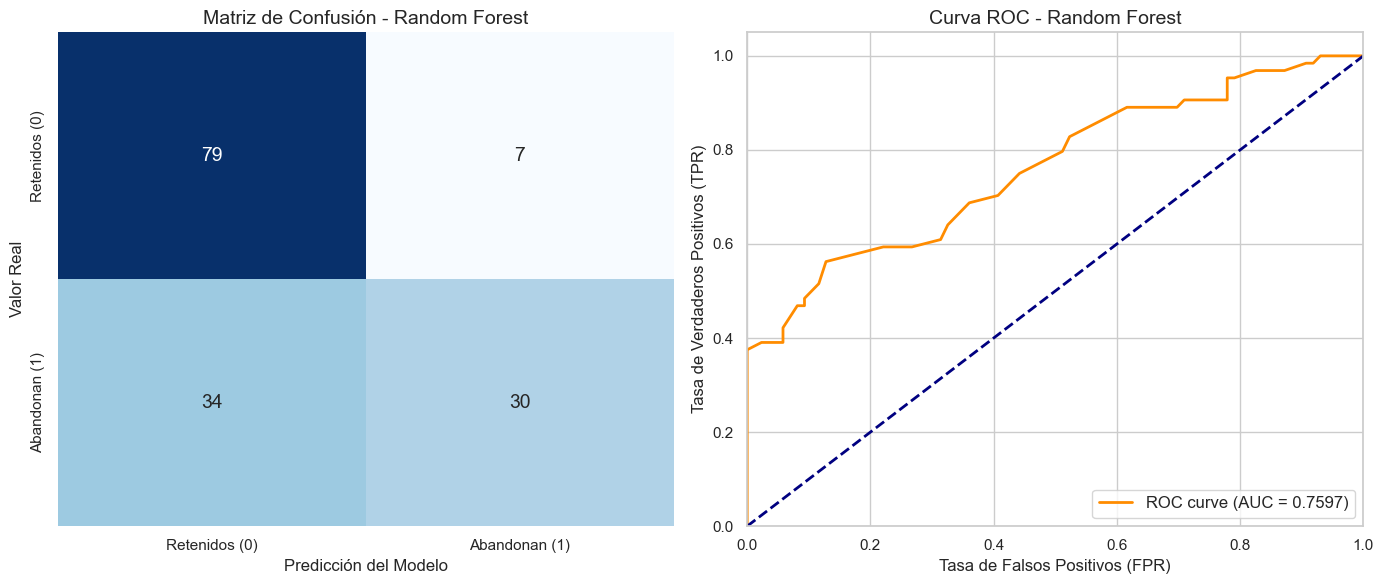

In [72]:
# ==========================================
# 4. GRÁFICOS Y ANÁLISIS DEL MEJOR MODELO
# ==========================================

# Determinar el mejor modelo basándonos en el AUC-ROC
best_model_name = "Regresión Logística" if metrics_lr['AUC-ROC'] > metrics_rf['AUC-ROC'] else "Random Forest"
y_pred_best = y_pred_lr if metrics_lr['AUC-ROC'] > metrics_rf['AUC-ROC'] else y_pred_rf
y_prob_best = y_prob_lr if metrics_lr['AUC-ROC'] > metrics_rf['AUC-ROC'] else y_prob_rf

print(f"\n---> Mejor Modelo Seleccionado (por AUC-ROC): {best_model_name} <---\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title(f'Matriz de Confusión - {best_model_name}', fontsize=14)
axes[0].set_xlabel('Predicción del Modelo', fontsize=12)
axes[0].set_ylabel('Valor Real', fontsize=12)
axes[0].set_xticklabels(['Retenidos (0)', 'Abandonan (1)'])
axes[0].set_yticklabels(['Retenidos (0)', 'Abandonan (1)'])

# 2. Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
auc_val = max(metrics_lr['AUC-ROC'], metrics_rf['AUC-ROC'])

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
axes[1].set_title(f'Curva ROC - {best_model_name}', fontsize=14)
axes[1].legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

**La división de los conjuntos de datos de entrenamiento y prueba con estratificación porque esto garantiza que haya un balance entre los conjuntos de datos, de manera que no haya sesgos, así como lo menciono a la hora de realizar esta "partición"**

Los falsos negativos representan aquellas predicciones de abandono de abandonos pero que realmente según la evaluación del modelo, esos pacientes no abandonaron los tratamientos. Los falsos positivos en cambio, son aquellas predicciones de pacientes de los que se predecía que iban a ser retenidos, pero en realidad abandonaron, estas dos métricas son muy importante para garantizar la precisión del modelo y de su predicción.

Este modelo de random forest nos muestra que tenemos predicciones muy buenas para aquellos tratamientos que serán retenidos.

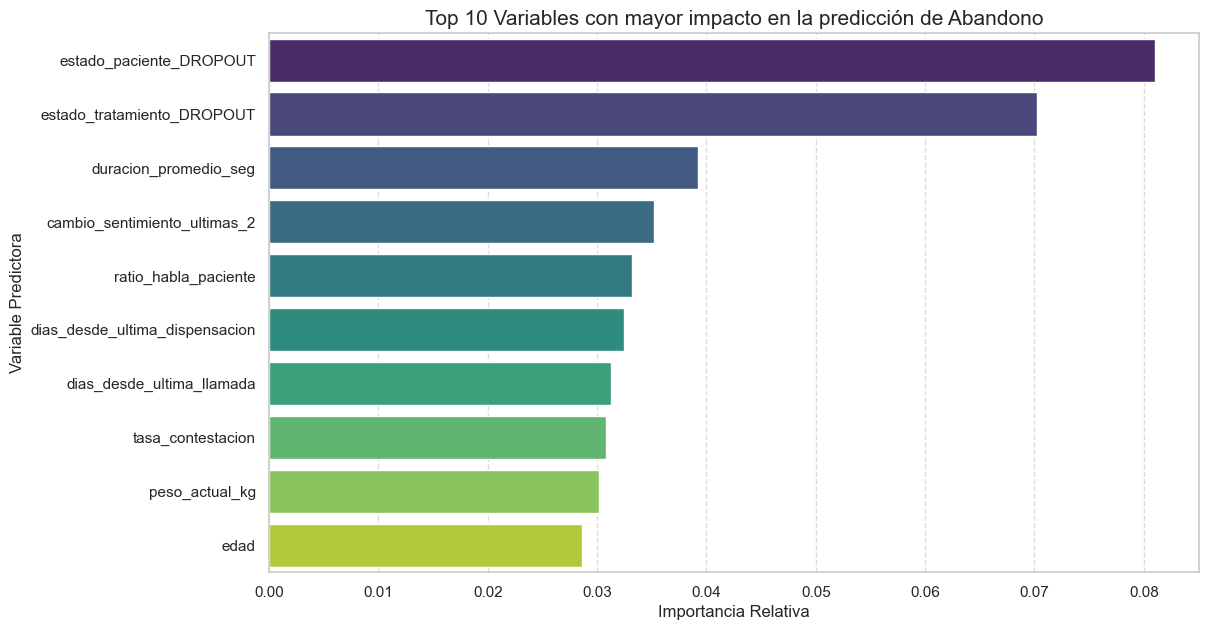


--- Resumen de las 10 variables más influyentes ---


,Variable,Importancia
0,estado_paciente_DROPOUT,0.081012
1,estado_tratamiento_DROPOUT,0.070199
2,duracion_promedio_seg,0.039219
3,cambio_sentimiento_ultimas_2,0.035209
4,ratio_habla_paciente,0.033224
5,dias_desde_ultima_dispensacion,0.032490
6,dias_desde_ultima_llamada,0.031290
7,tasa_contestacion,0.030771
8,peso_actual_kg,0.030211
9,edad,0.028592


In [73]:
# ==========================================
# ANÁLISIS DE IMPORTANCIA DE VARIABLES (Random Forest)
# ==========================================

# Extraer las importancias del modelo Random Forest entrenado previamente
importancias = rf_model.feature_importances_
nombres_features = X.columns

# Crear un DataFrame para organizar los resultados
df_importancias = pd.DataFrame({
    'Variable': nombres_features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Seleccionar las 10 más relevantes
top_10_features = df_importancias.head(10)

# Visualización gráfica
plt.figure(figsize=(12, 7))
sns.barplot(data=top_10_features, x='Importancia', y='Variable', palette='viridis')
plt.title('Top 10 Variables con mayor impacto en la predicción de Abandono', fontsize=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variable Predictora', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\n--- Resumen de las 10 variables más influyentes ---")
display(top_10_features.reset_index(drop=True))

## **Punto 4**

- Para priorizar a qué pacientes llamar de acuerdo a los resultados del modelo, primero deberíamos empezar por filtrar a aquellos pacientes cuyo estado es aún activo `estado_paciente = ACTIVE`,  y lo mismo ocurre para el estado de tratamiento, ya que como se ve en el entrenamiento, estas son las variables quee más influyen, y como estrategia de retención preventiva, lo mejor es priorizar aquellos que todavía están en los tratamientos. Y la otra idea es evitar saturar a los pacientes, por lo tanto, es oportuno descartar la priorización de aquellos que han sido contactados dentro de los últimos tres días. Una vez realizado este filtro, lo siguiente es usar el modelo para determinar la probabilidad de abandono de los pacientes restantes, lo primordial es priorizar a aquellos que tienen más riesgo o probabilidad de abandono. De esta lista ordenada tomaría a los primeros 50 que representen un mayor riesgo.

- La manera más oportuna de presentar estos resultados a un lider no técnico sería a través de visualizaciones y analogías. explicando a través de ejemplos lo que hace el modelo. Un caso puede ser presentar los resultados a manera de semáforo, señalando con colores verde, rojo y amarillo aquellos pacientes que requieren atención más urgente por riesgos de abandono. De esta forma, si existe un límite se llamadas, evitaremos gastar llamadas valiosas en pacientes que están de color verde y no tienen tanto riesgo de abandono, esto será muy explicativo para el lider, y entenderá de manera simple las prioridades.

## **Punto 5**

**No alcancé**, queda de tarea